### 라이브러리 임포트

In [1]:
# --------------------------------------------------
# [1] 라이브러리 임포트 및 시각화 설정 
# --------------------------------------------------
import duckdb
import polars as pl
import pandas as pd
import os
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# 🚨 반드시 Seaborn 임포트 이후에 폰트 설정 실행
if platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
elif platform.system() == 'Windows':  # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Google Colab 등) 환경
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [2]:
# --------------------------------------------------
# [2] 파일 경로 설정 및 데이터 로드
# --------------------------------------------------
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_final_mapped.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

# --------------------------------------------------
# [3] 데이터 정상 로드 확인
# --------------------------------------------------
query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
print("📌 [데이터 미리보기]")
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_final_mapped.parquet
파일 존재 여부: True

📌 [데이터 미리보기]


measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,measure_timestamp,sensor_id_matched,lat,lon,address,district
str,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,str,f64,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs],str,f64,f64,str,str
"""2020.4.4 10:00""","""V02Q1940078""",null,13.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,28128.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 16:00""","""V02Q1940078""",null,15.0,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,9479.0,null,null,1.0,null,null,null,null,0.07,0.02,null,0.11,0.05,null,1.12,1.05,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 16:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 22:00""","""V02Q1940078""",null,9.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,30.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.1,0.05,null,1.14,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 22:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 4:00""","""V02Q1940078""",null,6.3,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,26.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.11,0.04,null,1.15,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 04:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 10:00""","""V02Q1940078""",null,9.0,null,null,1.0,null,0.0,0.0,null,0.0,0.0,null,null,30247.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""


# 대기오염도 지표별 결측률

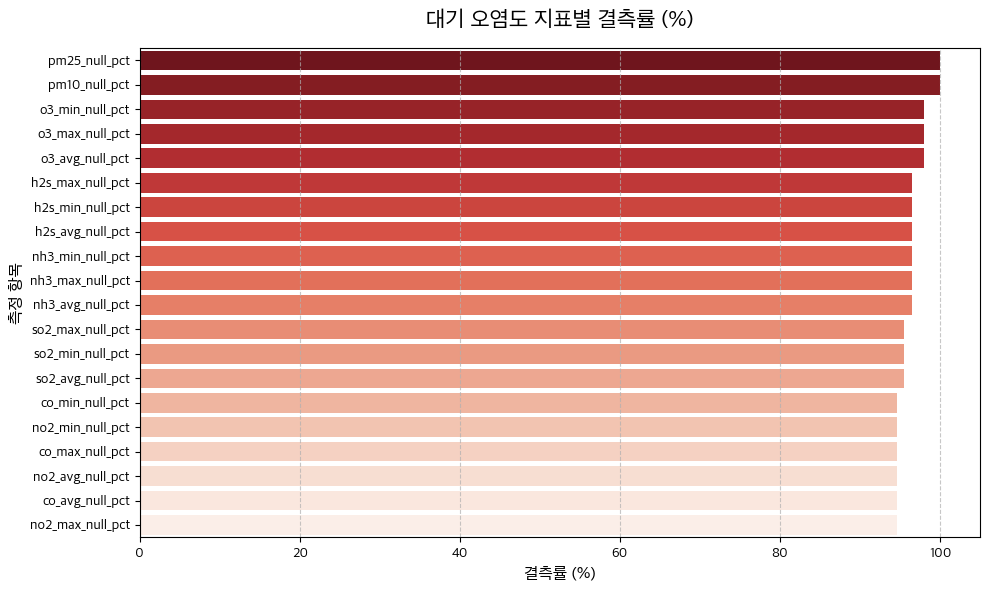

In [7]:
# 분석 대상 기상 컬럼
air_quality_cols = ['no2_min', 'no2_avg', 'no2_max',
                    'co_min', 'co_avg', 'co_max',
                    'so2_min', 'so2_avg', 'so2_max',
                    'nh3_min', 'nh3_avg', 'nh3_max',
                    'h2s_min', 'h2s_avg', 'h2s_max',
                    'o3_min', 'o3_avg', 'o3_max',
                    'pm10', 'pm25']

# DuckDB를 이용해 각 컬럼별 NULL 카운트 및 총 행 수 계산
null_queries = []
for col in air_quality_cols:
    null_queries.append(f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS {col}_null_pct")

query_missing = f"SELECT {', '.join(null_queries)} FROM v_sdot"
df_missing = duckdb.sql(query_missing).pl().to_pandas().T
df_missing.columns = ['결측률(%)']
df_missing = df_missing.sort_values(by='결측률(%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_missing['결측률(%)'], y=df_missing.index, hue=df_missing.index, palette='Reds_r', legend=False)

plt.title("대기 오염도 지표별 결측률 (%)", fontsize=16, pad=15)
plt.xlabel("결측률 (%)", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 연도별 월별 결측률 시각화

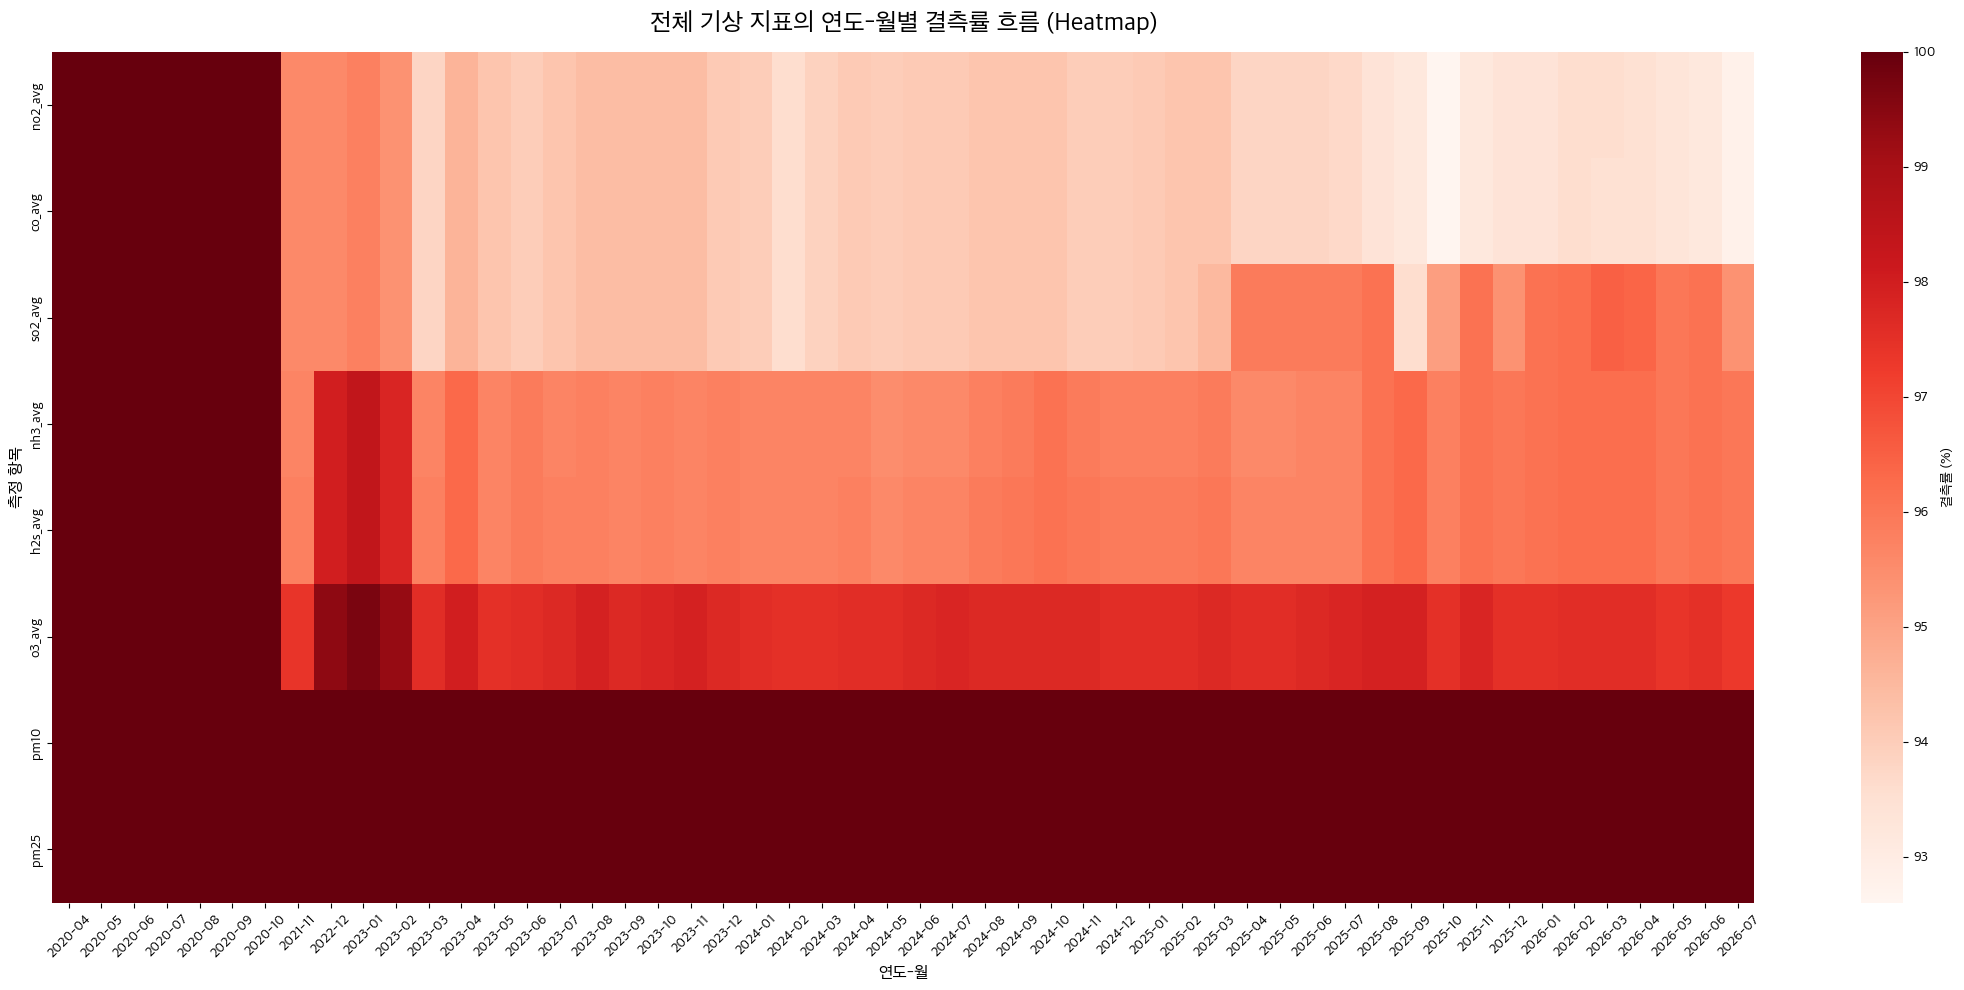

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

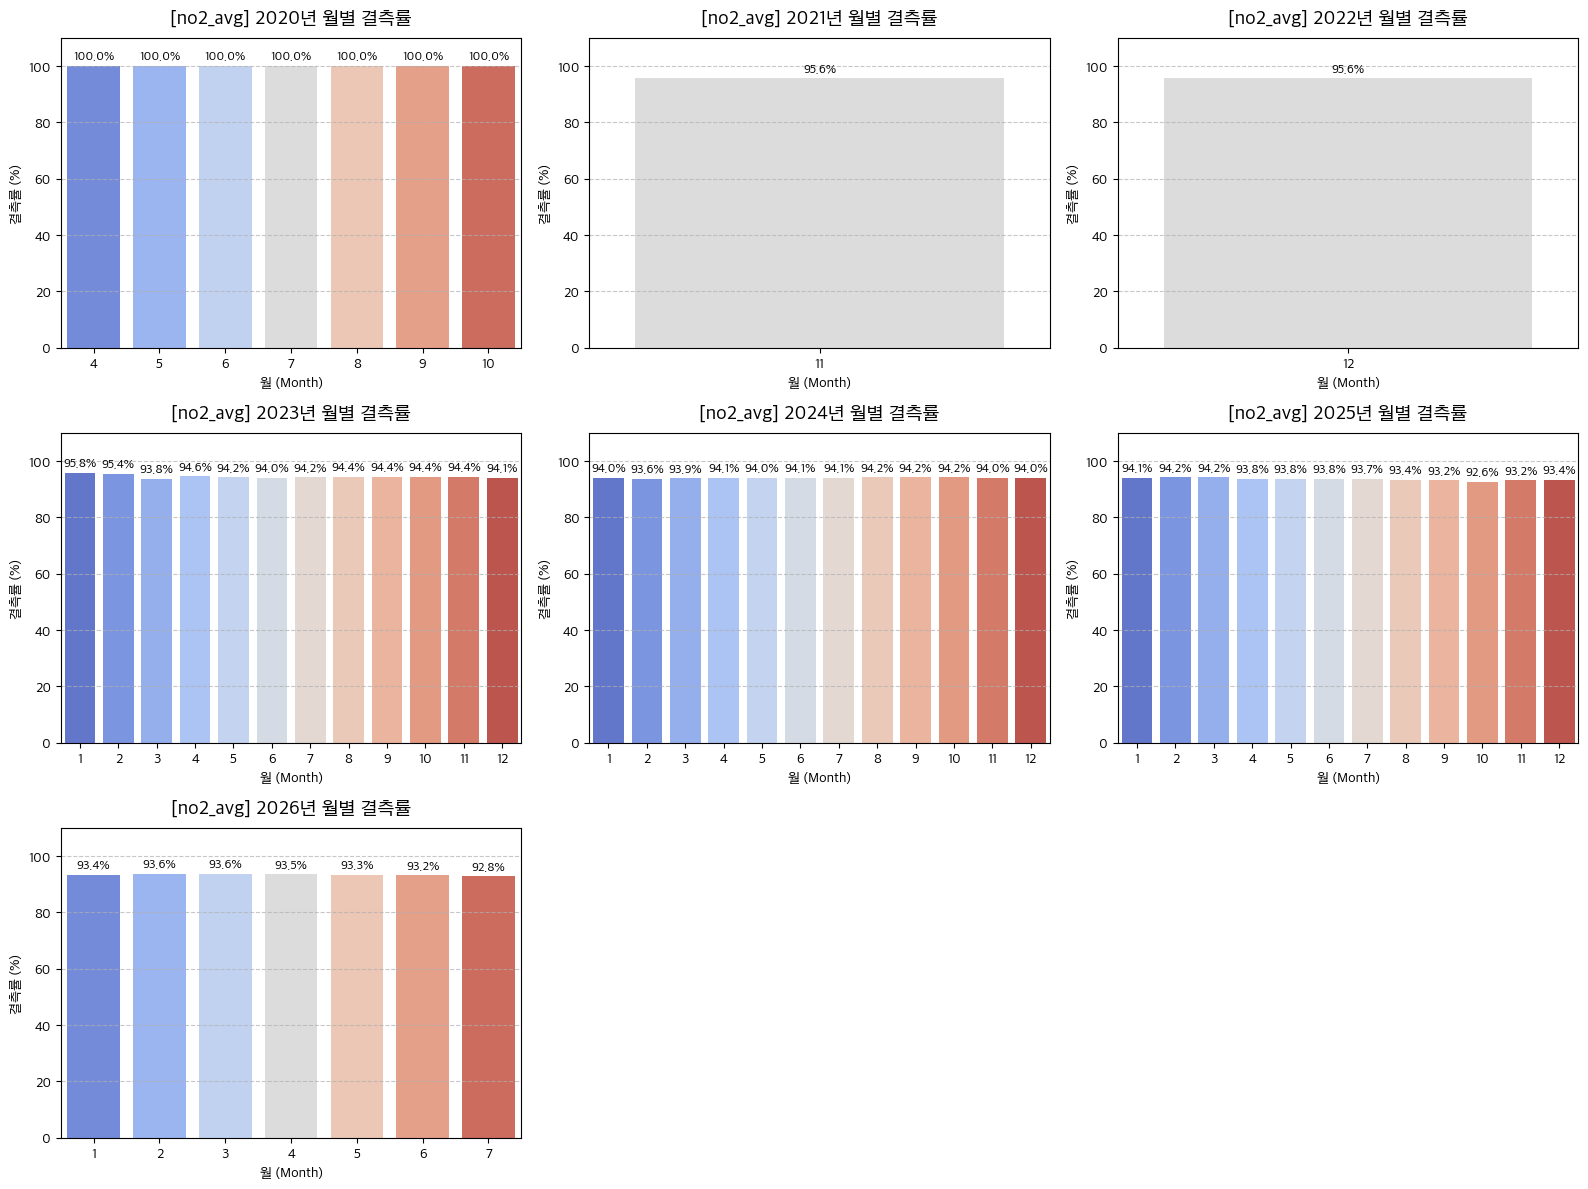

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

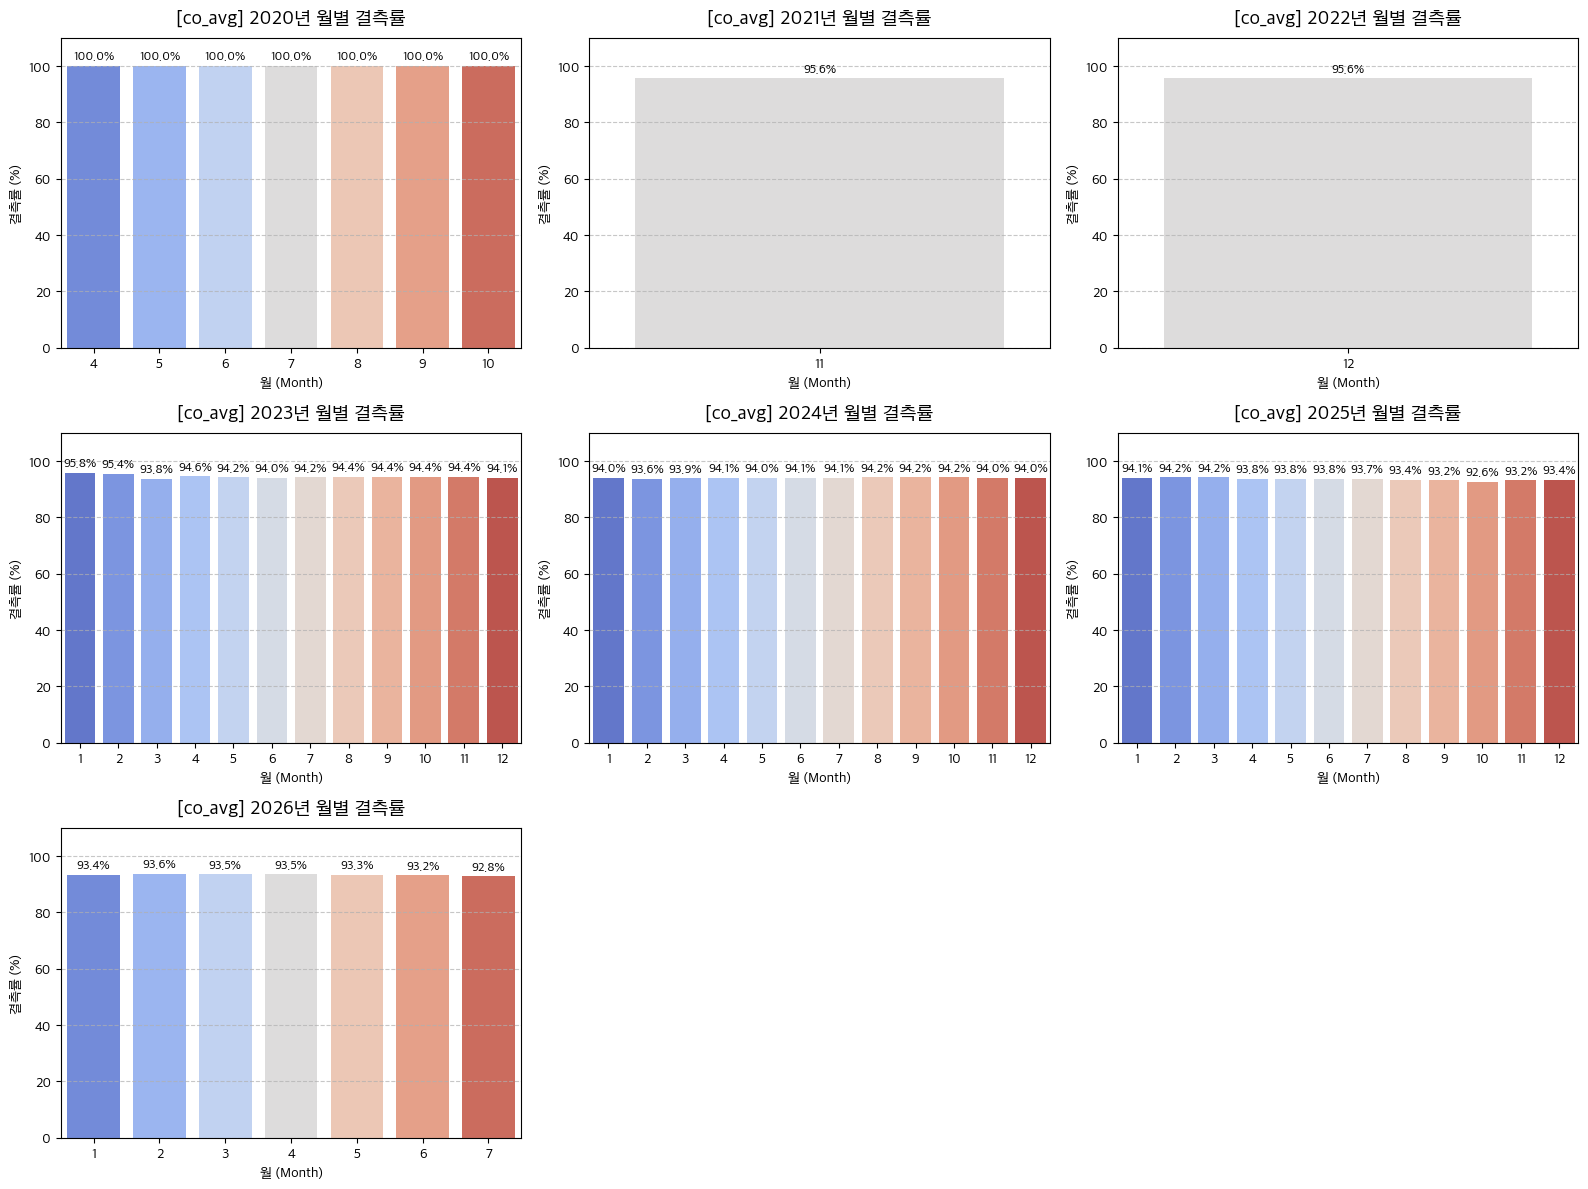

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

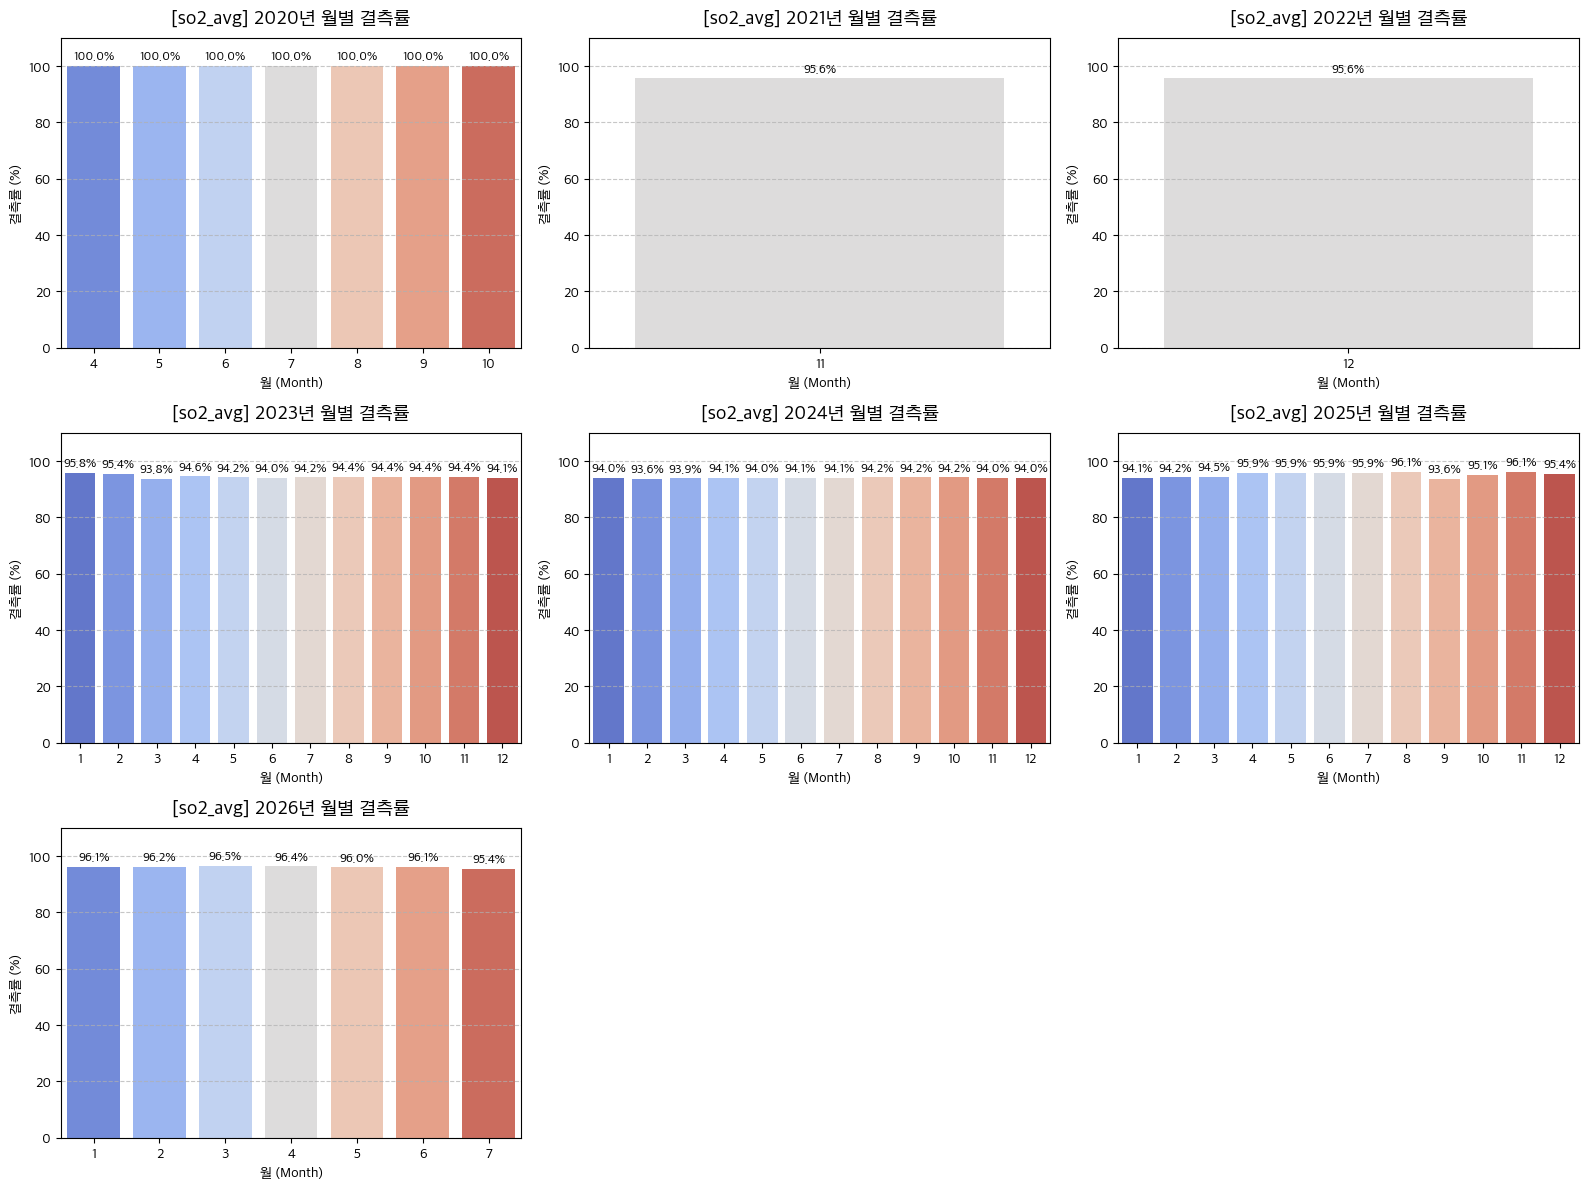

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

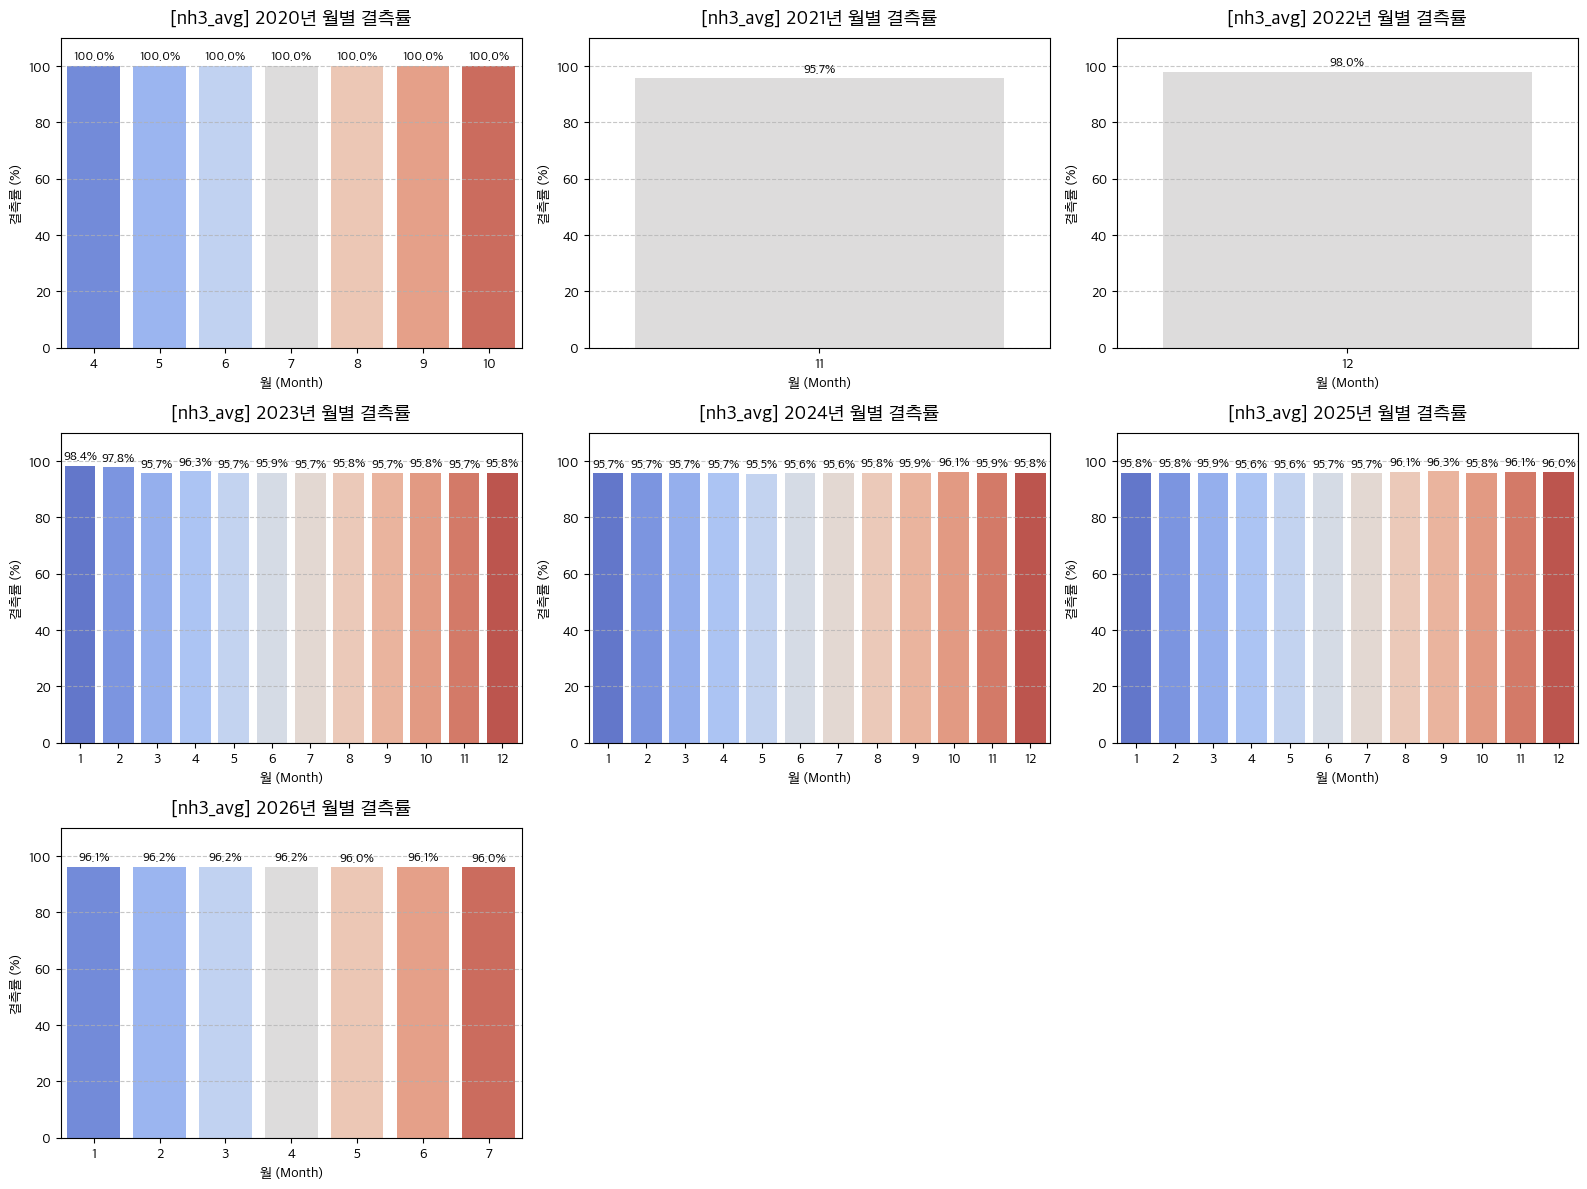

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

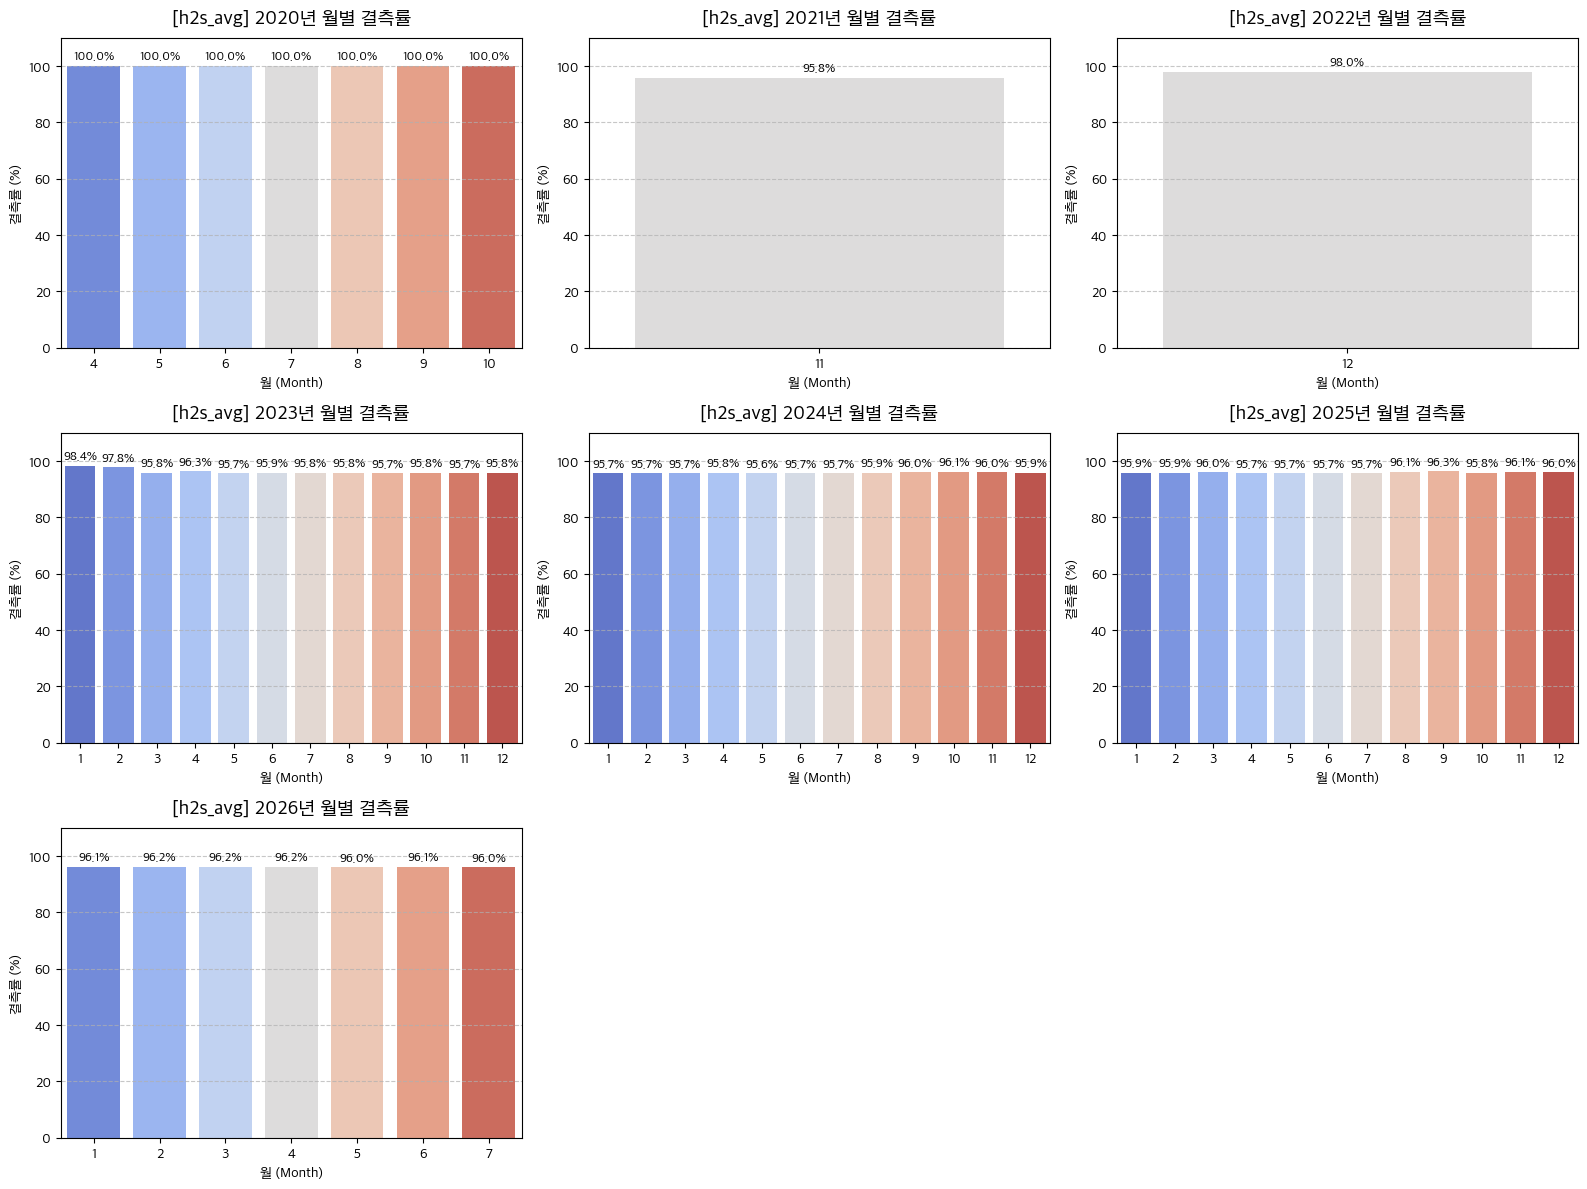

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

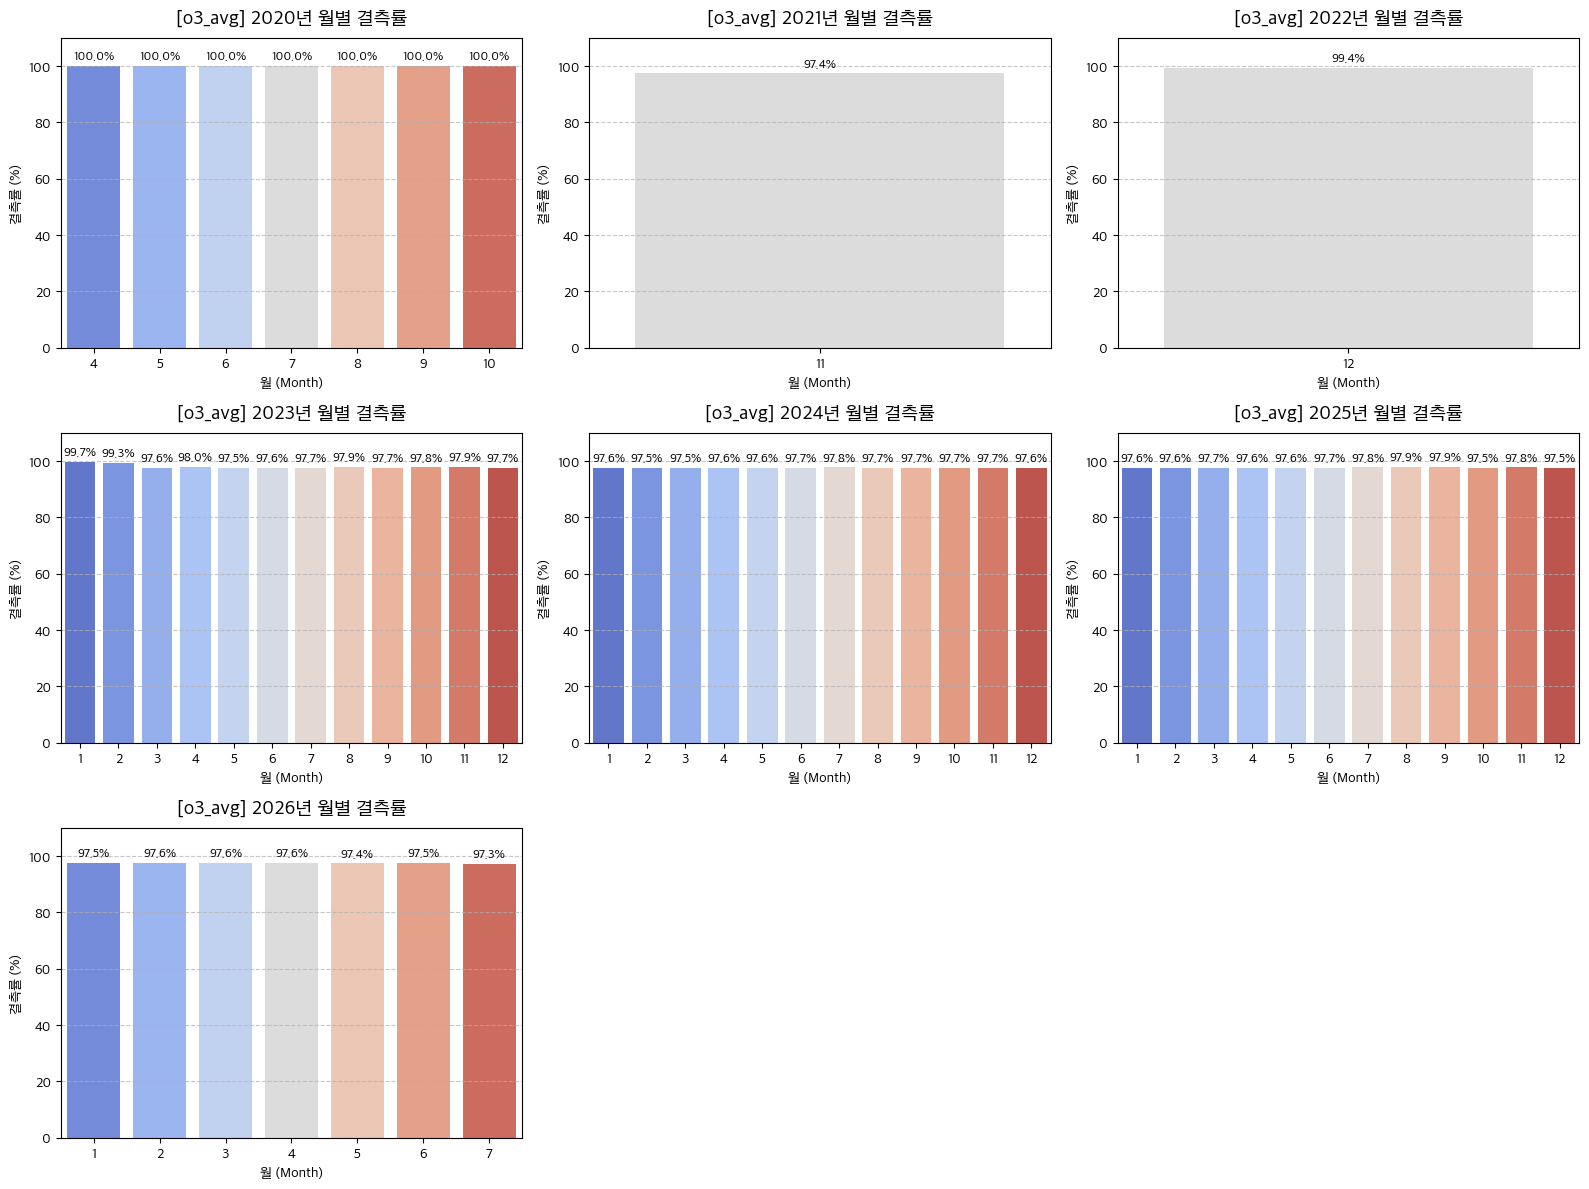

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

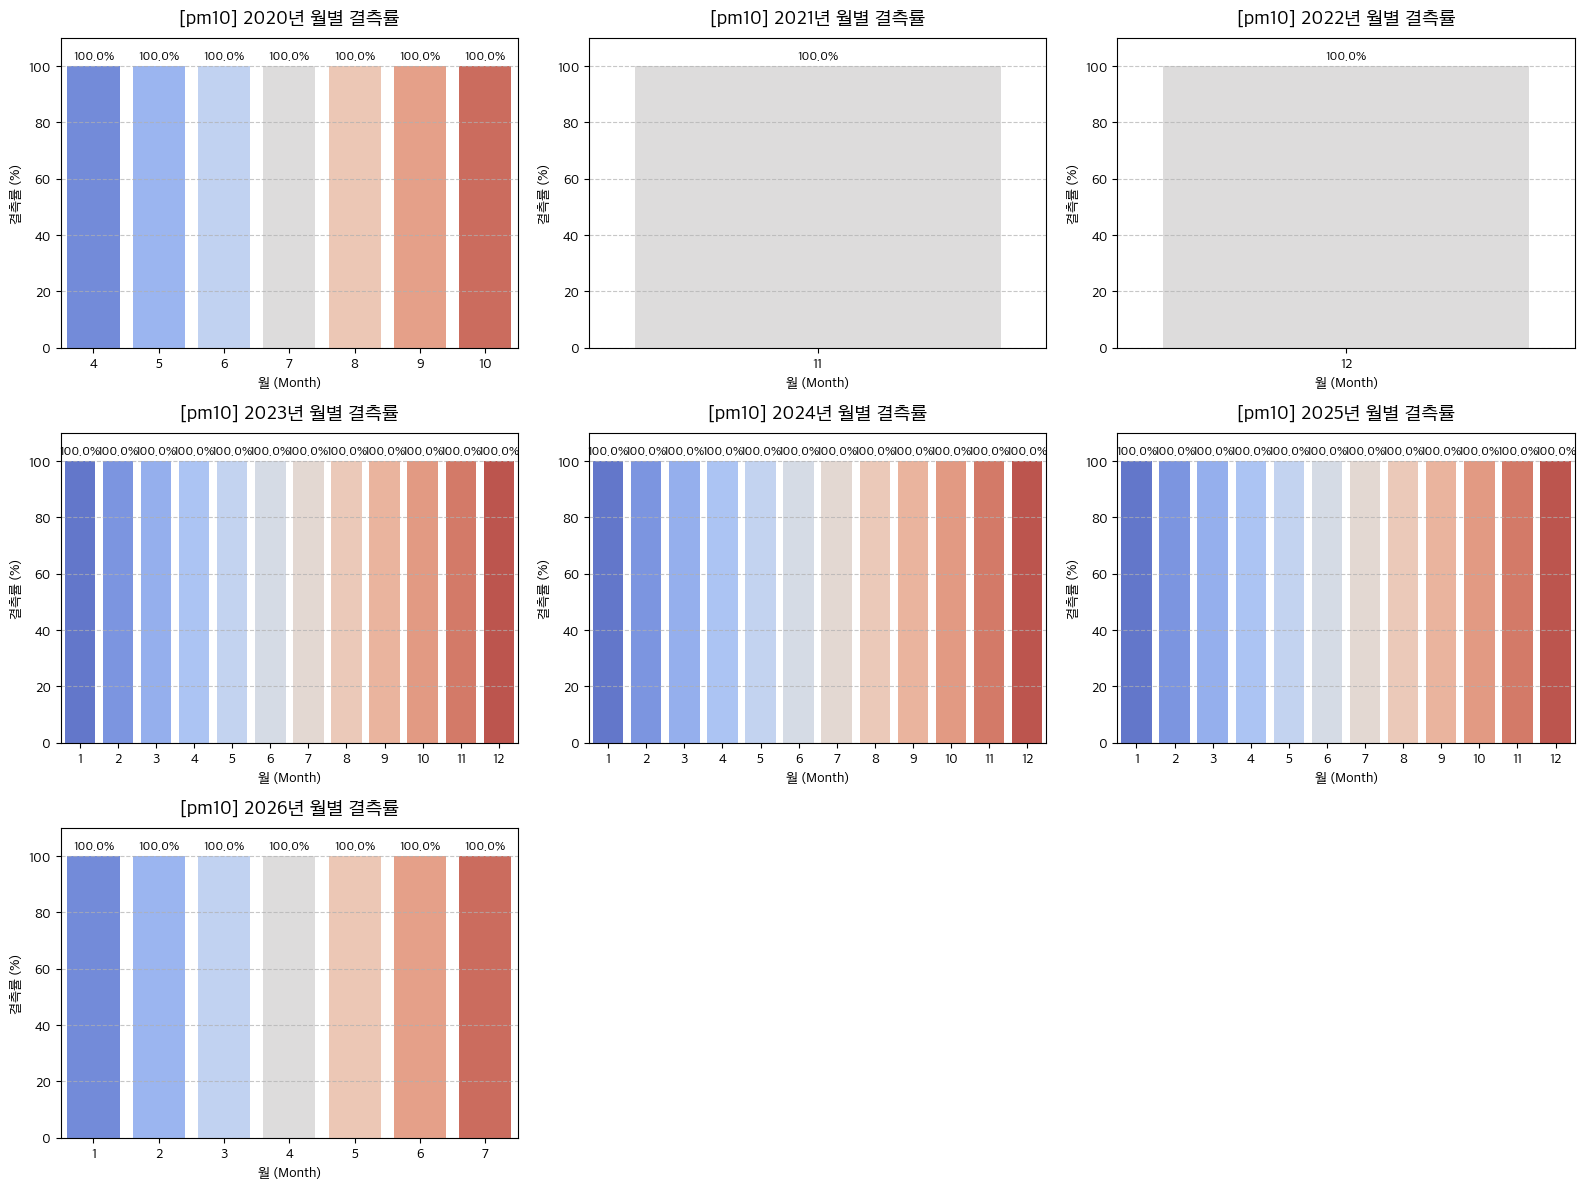

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_68614/2619057349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

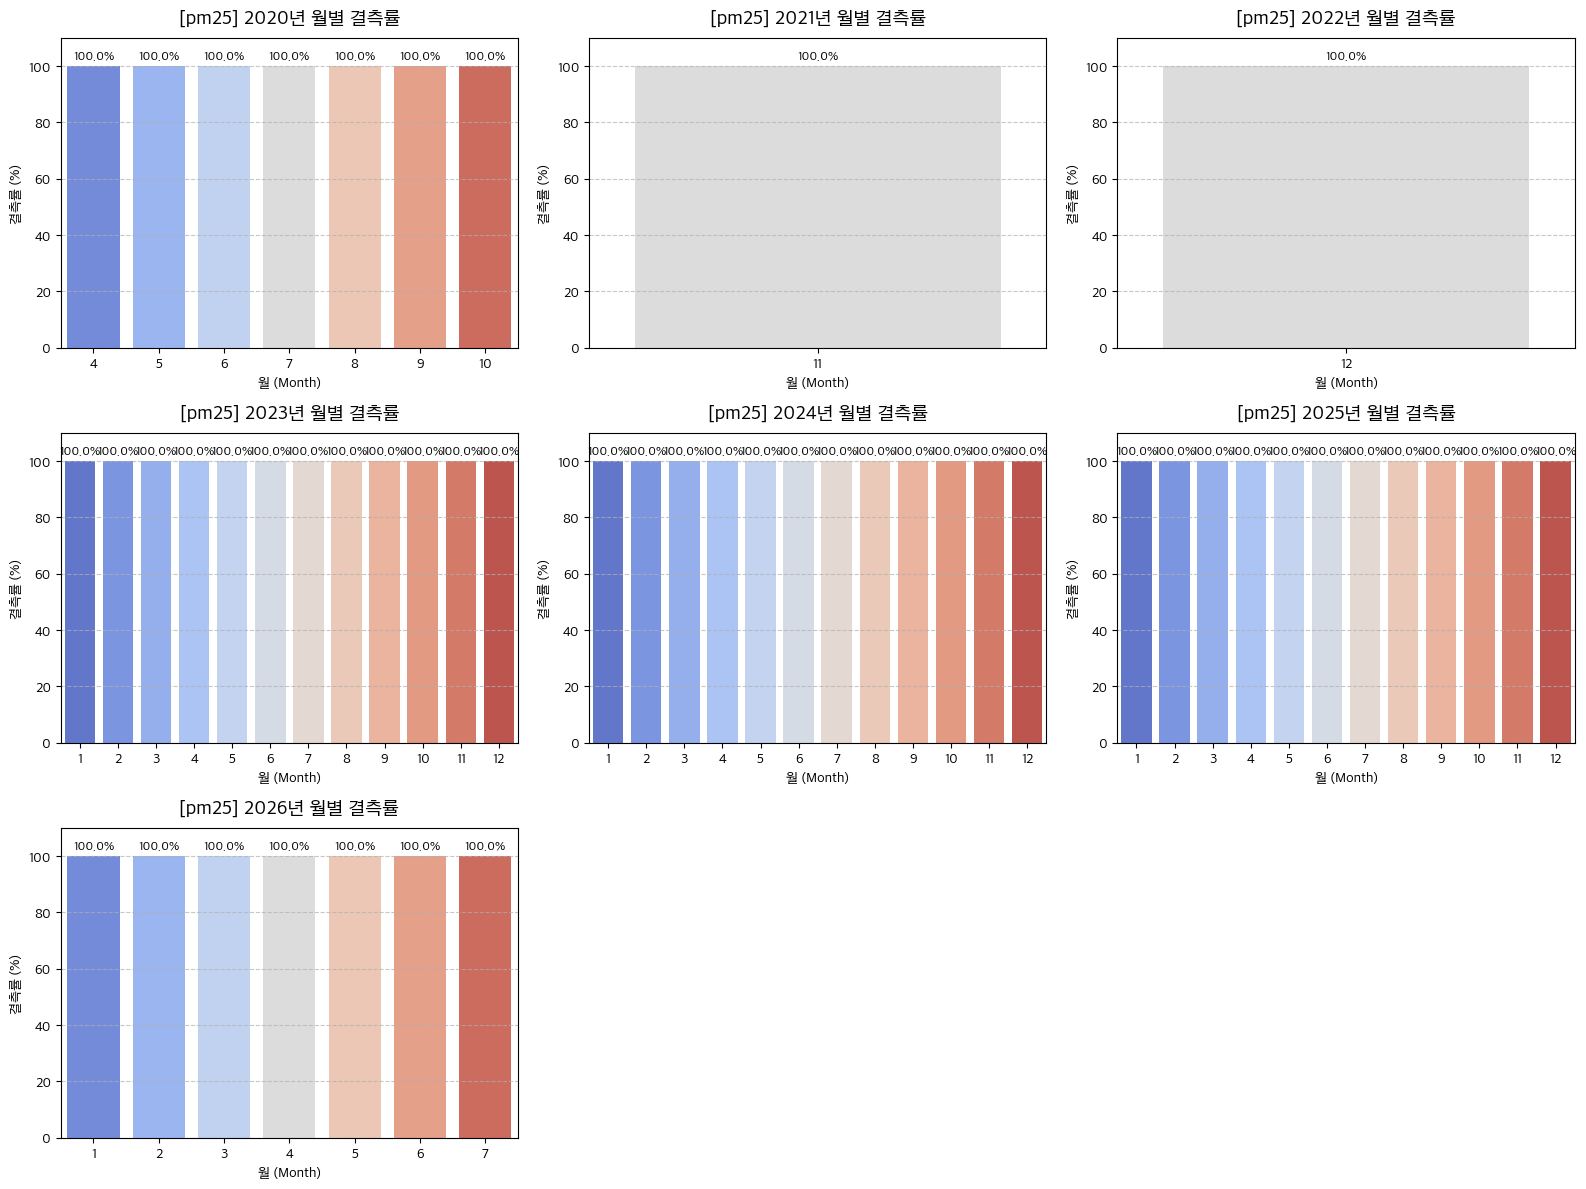

In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

air_quality_cols = ['no2_avg','co_avg', 'so2_avg','nh3_avg', 'h2s_avg', 'o3_avg', 'pm10', 'pm25']

# 1. 쿼리 생성: 모든 컬럼의 연-월별 결측률을 단일 쿼리로 계산
null_pct_sqls = [f"ROUND(SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS {col}" for col in air_quality_cols]
null_pct_sql_str = ",\n        ".join(null_pct_sqls)

query_all_seasonal = f"""
    SELECT 
        EXTRACT(year FROM measure_timestamp) AS year,
        EXTRACT(month FROM measure_timestamp) AS month,
        {null_pct_sql_str}
    FROM v_sdot
    GROUP BY year, month
    ORDER BY year, month
"""
df_all_seasonal = duckdb.sql(query_all_seasonal).df()

# --------------------------------------------------
# [시각화 1] 전체 지표 결측률 타임라인 히트맵 (거시적 관점)
# --------------------------------------------------
# 'YYYY-MM' 형식의 파생 컬럼 생성
df_all_seasonal['year_month'] = df_all_seasonal['year'].astype(int).astype(str) + '-' + df_all_seasonal['month'].astype(int).astype(str).str.zfill(2)
df_heatmap = df_all_seasonal.set_index('year_month')[air_quality_cols].T

plt.figure(figsize=(22, 10))
sns.heatmap(df_heatmap, cmap='Reds', annot=False, cbar_kws={'label': '결측률 (%)'})
plt.title("전체 기상 지표의 연도-월별 결측률 흐름 (Heatmap)", fontsize=18, pad=15)
plt.xlabel("연도-월", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# [시각화 2] 지표별 연도/월별 3열 Grid 바 차트 (미시적 관점)
# --------------------------------------------------
years = sorted(df_all_seasonal['year'].dropna().unique())
cols = 3
rows = math.ceil(len(years) / cols)

def plot_seasonal_nulls_for_item(item_name):
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4 * rows))
    axes = axes.flatten()
    
    for i, year in enumerate(years):
        ax = axes[i]
        year_data = df_all_seasonal[df_all_seasonal['year'] == year]
        
        sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
        
        ax.set_title(f"[{item_name}] {int(year)}년 월별 결측률", fontsize=14, pad=10)
        ax.set_xlabel("월 (Month)", fontsize=10)
        ax.set_ylabel("결측률 (%)", fontsize=10)
        ax.set_ylim(0, 110) # 텍스트 잘림 방지
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 막대 위에 % 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{height}%", 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', fontsize=9, color='black', 
                            xytext=(0, 4), textcoords='offset points')
                            
    # 데이터가 없는 남은 subplot 숨기기
    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# 21개 지표 모두에 대해 Grid 그래프 반복 출력
for col in air_quality_cols:
    plot_seasonal_nulls_for_item(col)

# 대기 오염도 지표별 수집 간격

In [9]:
air_quality_cols = ['no2_min', 'no2_avg', 'no2_max',
                    'co_min', 'co_avg', 'co_max',
                    'so2_min', 'so2_avg', 'so2_max',
                    'nh3_min', 'nh3_avg', 'nh3_max',
                    'h2s_min', 'h2s_avg', 'h2s_max',
                    'o3_min', 'o3_avg', 'o3_max',
                    'pm10', 'pm25']

# 1. SELECT 절에서 모든 대상 컬럼을 명시적으로 DOUBLE형으로 캐스팅
casted_cols = [f"TRY_CAST({col} AS DOUBLE) AS {col}" for col in air_quality_cols]
air_quality_cols_cast_str = ", ".join(casted_cols)
# 2. UNPIVOT ON 절에는 컬럼 이름만 필요
air_quality_cols_str = ", ".join(air_quality_cols) 

query_interval = f"""
    WITH gap_calc AS (
        SELECT 
            sensor_id_matched,
            measure_timestamp,
            DATE_DIFF('minute', 
                      LAG(measure_timestamp) OVER(PARTITION BY sensor_id_matched ORDER BY measure_timestamp), 
                      measure_timestamp) AS time_gap_minutes,
            {air_quality_cols_cast_str}
        FROM v_sdot
    ),
    unpivoted_gaps AS (
        UNPIVOT gap_calc
        ON {air_quality_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    )
    SELECT 
        measure_type AS 측정_항목,
        MEDIAN(time_gap_minutes) AS 중앙값_간격_분,
        ROUND(AVG(time_gap_minutes), 1) AS 평균_간격_분
    FROM unpivoted_gaps
    WHERE measure_value IS NOT NULL
      AND time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 중앙값_간격_분 ASC, 측정_항목 ASC
"""
df_interval = duckdb.sql(query_interval).pl().to_pandas()

print("📌 [대기 오염도 지표별 실제 측정 주기]")
display(df_interval)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [대기 오염도 지표별 실제 측정 주기]


,측정_항목,중앙값_간격_분,평균_간격_분
0,co_avg,60.0,101.3
1,co_max,60.0,101.3
2,co_min,60.0,101.3
3,h2s_avg,60.0,113.5
4,h2s_max,60.0,115.7
5,h2s_min,60.0,113.5
6,nh3_avg,60.0,115.8
7,nh3_max,60.0,115.8
8,nh3_min,60.0,115.8
9,no2_avg,60.0,101.3


# 대기 오염도 지표별 수집 누락 비율

In [ ]:
query_missing_freq = f"""
    WITH unpivoted_data AS (
        UNPIVOT (
            SELECT 
                sensor_id_matched, 
                measure_timestamp, 
                {air_quality_cols_cast_str}
            FROM v_sdot
        )
        ON {air_quality_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    ),
    gap_calc AS (
        SELECT 
            measure_type,
            DATE_DIFF('minute', 
                      LAG(measure_timestamp) OVER(PARTITION BY sensor_id_matched, measure_type ORDER BY measure_timestamp), 
                      measure_timestamp) AS time_gap_minutes
        FROM unpivoted_data
        WHERE measure_value IS NOT NULL
    )
    SELECT 
        measure_type AS 측정_항목,
        COUNT(*) AS 총_수집_횟수,
        SUM(CASE WHEN time_gap_minutes > 65 THEN 1 ELSE 0 END) AS 지연_및_누락_횟수,
        ROUND(SUM(CASE WHEN time_gap_minutes > 65 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS 누락_발생_비율_pct
    FROM gap_calc
    WHERE time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 누락_발생_비율_pct DESC
"""
df_missing_freq = duckdb.sql(query_missing_freq).pl().to_pandas()

print("📌 [대기 오염도 지표별 통신 단절 및 수집 누락 발생 비율]")
display(df_missing_freq)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [대기 오염도 지표별 통신 단절 및 수집 누락 발생 비율]


,측정_항목,총_수집_횟수,지연_및_누락_횟수,누락_발생_비율_pct
0,h2s_min,1031745,83519,8.09
1,h2s_avg,1031877,83486,8.09
2,o3_max,588555,47184,8.02
3,o3_avg,588618,47142,8.01
4,o3_min,588534,47163,8.01
5,h2s_max,1006600,59595,5.92
6,nh3_max,1016454,60025,5.91
7,nh3_avg,1016554,59960,5.90
8,nh3_min,1016424,59993,5.90
9,so2_max,1300271,70975,5.46


: 

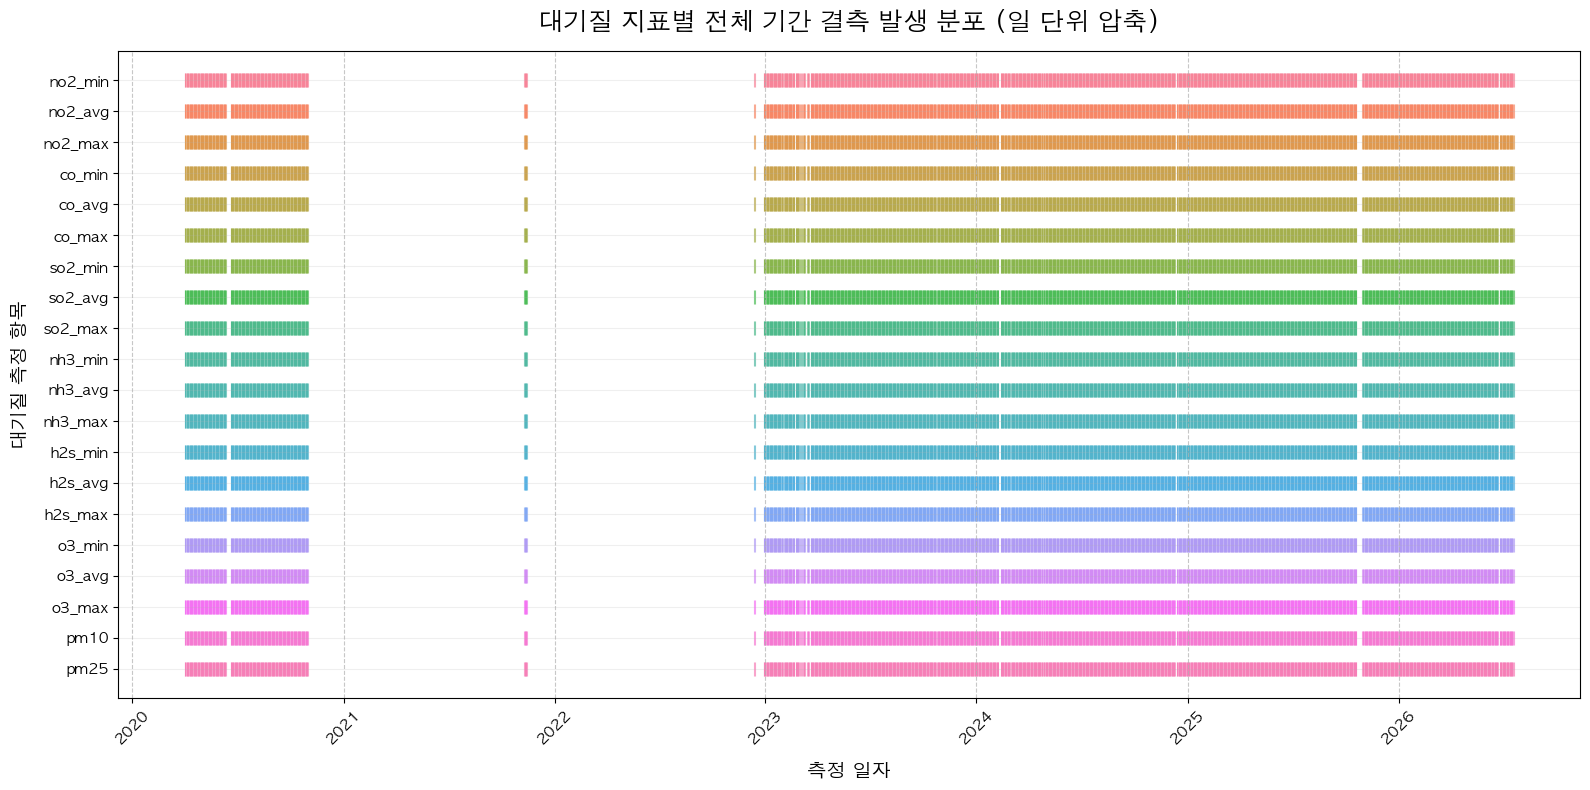

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic') # Windows
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

air_quality_cols = [
    'no2_min', 'no2_avg', 'no2_max',
    'co_min', 'co_avg', 'co_max',
    'so2_min', 'so2_avg', 'so2_max',
    'nh3_min', 'nh3_avg', 'nh3_max',
    'h2s_min', 'h2s_avg', 'h2s_max',
    'o3_min', 'o3_avg', 'o3_max',
    'pm10', 'pm25'
]

# --------------------------------------------------
# 1. 초경량화 데이터 추출: DISTINCT DATE() 활용
# --------------------------------------------------
# 수백만 건의 원본 데이터 대신, "결측이 발생한 날짜"만 중복 없이 가져옵니다.
# 아무리 데이터가 많아도 (전체 일수 x 20개 지표) 건수 이상을 넘지 않아 매우 가볍습니다.
queries = []
for col in air_quality_cols:
    q = f"""
        SELECT DISTINCT DATE(measure_timestamp) AS measure_date, '{col}' AS indicator 
        FROM v_sdot 
        WHERE {col} IS NULL
    """
    queries.append(q)

query_lightweight = " UNION ALL ".join(queries)

# 쿼리 실행 (순식간에 끝납니다!)
df_missing_scatter = duckdb.sql(query_lightweight).df()
df_missing_scatter['measure_date'] = pd.to_datetime(df_missing_scatter['measure_date'])

# --------------------------------------------------
# 2. 산점도(Scatter Plot) 시각화
# --------------------------------------------------
plt.figure(figsize=(16, 8))

if df_missing_scatter.empty:
    print("🚨 결측 데이터가 없습니다.")
else:
    # y축 정렬
    order_list = list(reversed(air_quality_cols))
    
    sns.scatterplot(
        data=df_missing_scatter, 
        x='measure_date', 
        y='indicator', 
        hue='indicator',   
        marker='|',        
        s=100,             # 일 단위이므로 마커 크기를 키워 연속성을 강조
        alpha=0.6,         
        legend=False       
    )

    plt.title('대기질 지표별 전체 기간 결측 발생 분포 (일 단위 압축)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('측정 일자', fontsize=14, labelpad=10)
    plt.ylabel('대기질 측정 항목', fontsize=14, labelpad=10)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.grid(axis='y', linestyle='-', alpha=0.2)

    plt.yticks(fontsize=11)
    plt.xticks(fontsize=11, rotation=45)

    plt.tight_layout()
    plt.show()

# 연도별 시간대별 대기 오염도

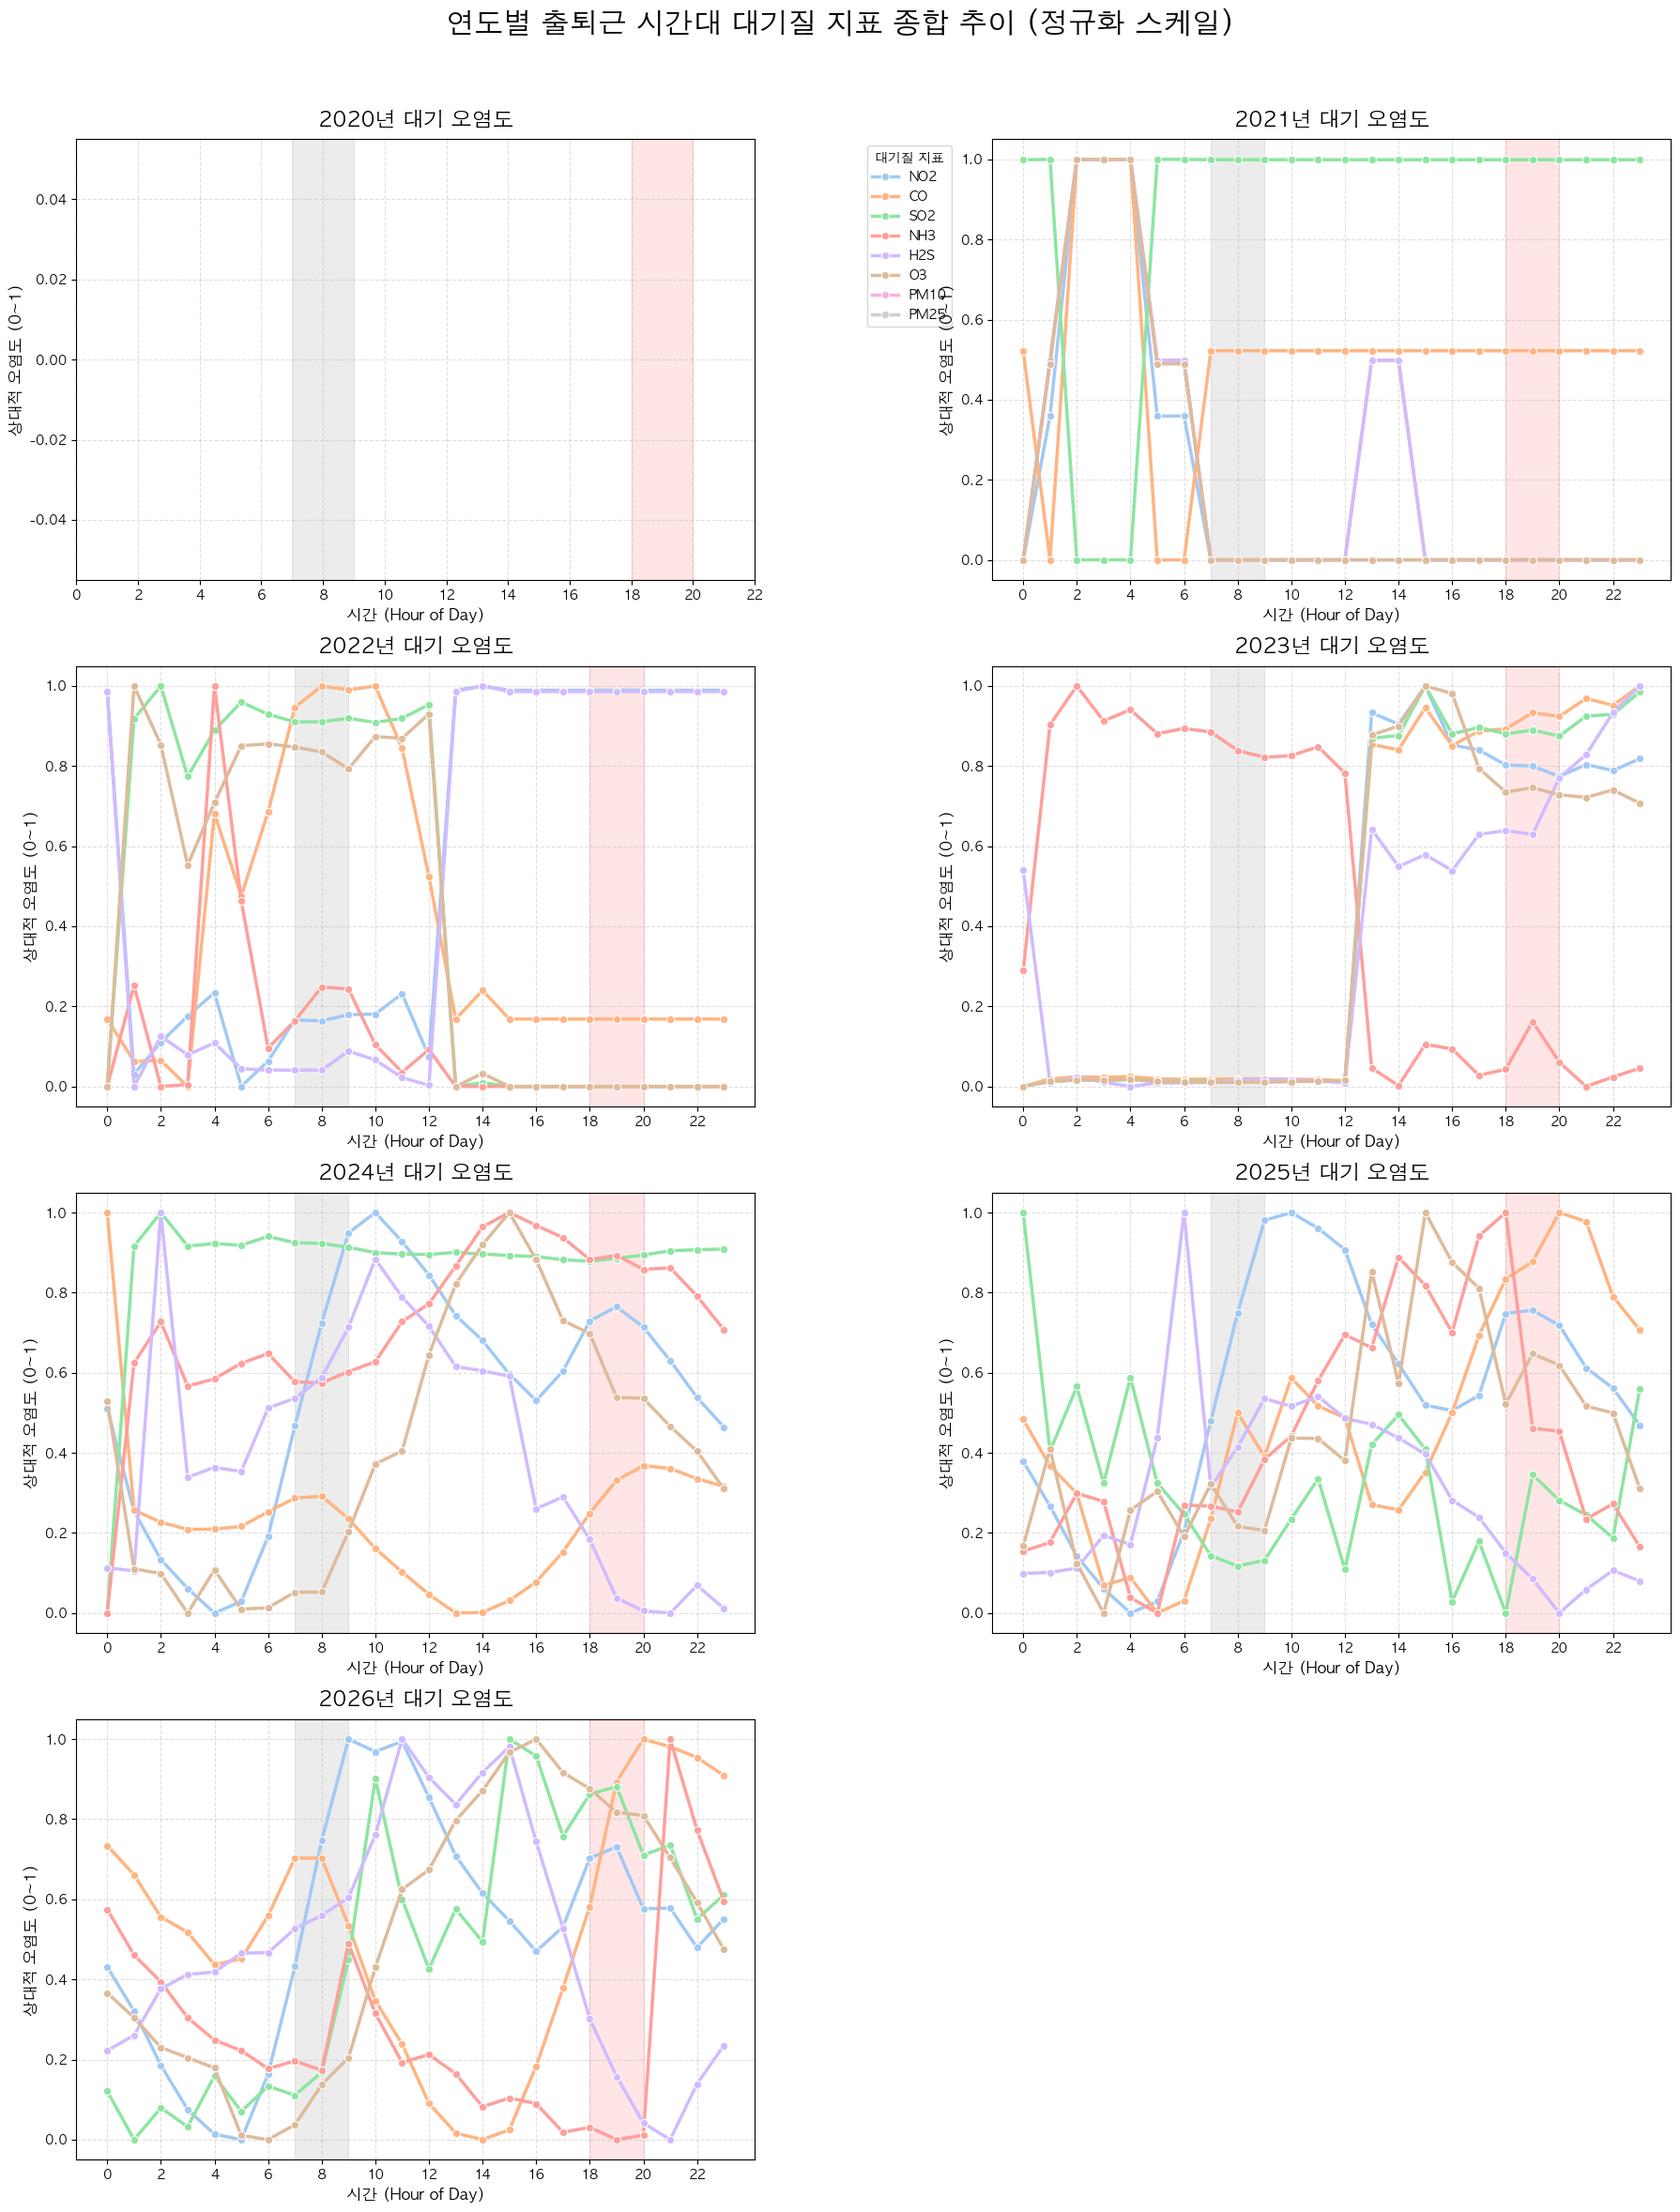

In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic') # Windows
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

air_quality_cols = ['no2_avg', 'co_avg', 'so2_avg', 'nh3_avg', 'h2s_avg', 'o3_avg', 'pm10', 'pm25']

# --------------------------------------------------
# 1. 연도별, 시간대별 대기 오염도 평균 추출
# --------------------------------------------------
select_avgs = ",\n        ".join([f"AVG(TRY_CAST({col} AS DOUBLE)) AS avg_{col}" for col in air_quality_cols])

query = f"""
    SELECT 
        CAST(EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) AS INTEGER) AS measure_year,
        CAST(EXTRACT(HOUR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) AS INTEGER) AS hour_of_day,
        {select_avgs}
    FROM v_sdot
    WHERE EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) BETWEEN 2020 AND 2026
    GROUP BY measure_year, hour_of_day
    ORDER BY measure_year, hour_of_day
"""

df = duckdb.sql(query).df()
df['measure_year'] = df['measure_year'].astype(str)

# --------------------------------------------------
# 2. Min-Max 정규화 (0~1 스케일링)
# --------------------------------------------------
for year in df['measure_year'].unique():
    for col in air_quality_cols:
        mask = df['measure_year'] == year
        min_val = df.loc[mask, f'avg_{col}'].min()
        max_val = df.loc[mask, f'avg_{col}'].max()
        
        if max_val != min_val:
            df.loc[mask, f'{col}_scaled'] = (df.loc[mask, f'avg_{col}'] - min_val) / (max_val - min_val)
        else:
            df.loc[mask, f'{col}_scaled'] = 0

# --------------------------------------------------
# 3. 시각화: 연도별 4x2 서브플롯 구성 (2020~2026, 7개 연도)
# --------------------------------------------------
years = [str(y) for y in range(2020, 2027)]
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

fig.suptitle('연도별 출퇴근 시간대 대기질 지표 종합 추이 (정규화 스케일)', fontsize=22, fontweight='bold', y=0.98)

# 채도가 낮고 밝은 파스텔 톤 팔레트 적용 (눈의 피로도 감소)
palette = sns.color_palette("pastel", n_colors=len(air_quality_cols))

for i, year in enumerate(years):
    ax = axes[i]
    df_year = df[df['measure_year'] == year]
    
    # 해당 연도에 데이터가 없으면 건너뜀
    if df_year.empty:
        ax.set_title(f'{year}년 (데이터 없음)', fontsize=15, color='gray')
        ax.axis('off')
        continue

    # 지표별 라인 플롯
    for j, col in enumerate(air_quality_cols):
        sns.lineplot(
            data=df_year, 
            x='hour_of_day', 
            y=f'{col}_scaled', 
            label=col.replace('_avg', '').upper(), 
            color=palette[j],
            linewidth=2.5,
            marker='o',
            ax=ax
        )
    
    # 출퇴근 시간대 음영 표시
    ax.axvspan(7, 9, color='gray', alpha=0.15)
    ax.axvspan(18, 20, color='red', alpha=0.1)
    
    ax.set_title(f'{year}년 대기 오염도', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('시간 (Hour of Day)', fontsize=12)
    ax.set_ylabel('상대적 오염도 (0~1)', fontsize=12)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(axis='both', linestyle='--', alpha=0.4)
    
    # 범례는 첫 번째 그래프에만 통합하여 표시
    if i == 0:
        ax.legend(title='대기질 지표', loc='upper right', bbox_to_anchor=(1.3, 1))
    else:
        ax.get_legend().remove()

# 8번째(마지막) 빈 서브플롯 숨기기
axes[7].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

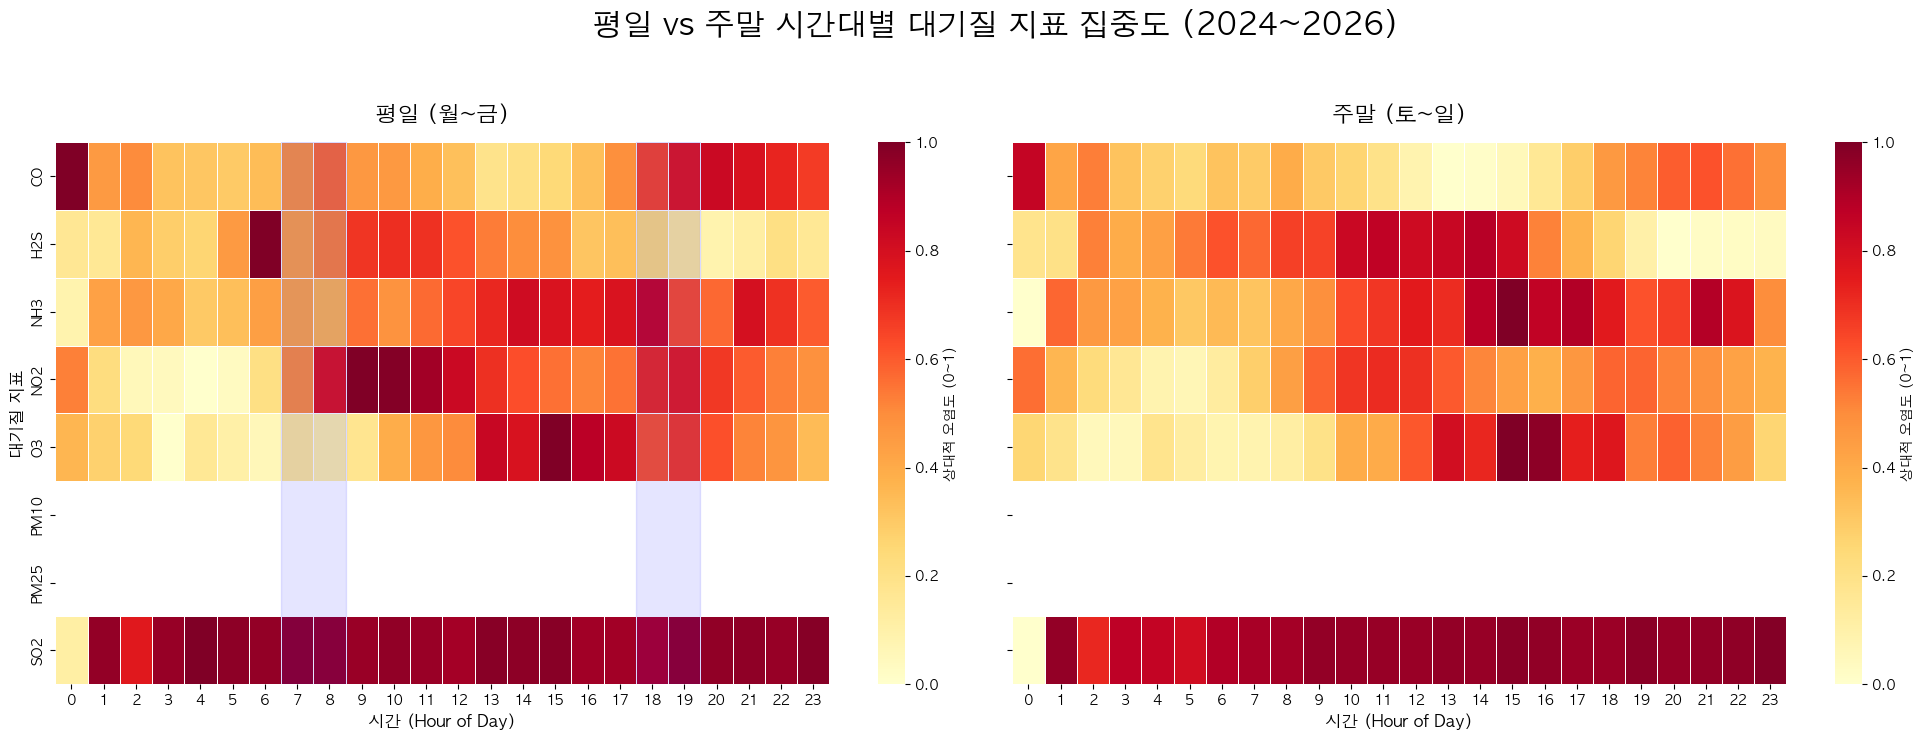

In [10]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic') # Windows
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

air_quality_cols = ['no2_avg', 'co_avg', 'so2_avg', 'nh3_avg', 'h2s_avg', 'o3_avg', 'pm10', 'pm25']

# --------------------------------------------------
# 1. 2024~2026년 데이터 추출 및 평일/주말 분리
# --------------------------------------------------
select_avgs = ",\n        ".join([f"AVG(TRY_CAST({col} AS DOUBLE)) AS {col}" for col in air_quality_cols])

# ISODOW 기준: 1(월요일) ~ 7(일요일). 즉, 6과 7이 주말입니다.
query = f"""
    SELECT 
        CAST(EXTRACT(HOUR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) AS INTEGER) AS hour_of_day,
        CASE 
            WHEN EXTRACT(ISODOW FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) IN (6, 7) THEN '주말'
            ELSE '평일' 
        END AS day_type,
        {select_avgs}
    FROM v_sdot
    WHERE EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) BETWEEN 2024 AND 2026
    GROUP BY hour_of_day, day_type
"""

df = duckdb.sql(query).df()

# --------------------------------------------------
# 2. 히트맵을 위한 데이터 전처리 (Melt -> Scaling -> Pivot)
# --------------------------------------------------
# 지표들을 하나의 컬럼으로 길게 펴기(Melt)
df_melted = df.melt(id_vars=['hour_of_day', 'day_type'], value_vars=air_quality_cols, var_name='indicator', value_name='value')

# 지표별 단위가 다르므로, 지표(indicator)별로 0~1 스케일링
df_melted['scaled_value'] = df_melted.groupby('indicator')['value'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
)

# 지표명을 대문자로 깔끔하게 변경 (예: no2_avg -> NO2)
df_melted['indicator'] = df_melted['indicator'].str.replace('_avg', '').str.upper()

# 평일과 주말 데이터 분리 후 Pivot (index: 지표, columns: 시간)
df_weekday = df_melted[df_melted['day_type'] == '평일'].pivot(index='indicator', columns='hour_of_day', values='scaled_value')
df_weekend = df_melted[df_melted['day_type'] == '주말'].pivot(index='indicator', columns='hour_of_day', values='scaled_value')

# --------------------------------------------------
# 3. 시각화: 1x2 서브플롯 히트맵
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
fig.suptitle('평일 vs 주말 시간대별 대기질 지표 집중도 (2024~2026)', fontsize=22, fontweight='bold', y=1.05)

# 컬러맵 설정 (붉은색 계열로 오염도가 높을수록 진하게 표시)
cmap = 'YlOrRd'

# 평일 히트맵
sns.heatmap(df_weekday, cmap=cmap, ax=axes[0], cbar_kws={'label': '상대적 오염도 (0~1)'}, linewidths=.5)
axes[0].set_title('평일 (월~금)', fontsize=16, pad=15)
axes[0].set_xlabel('시간 (Hour of Day)', fontsize=12)
axes[0].set_ylabel('대기질 지표', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# 평일 출퇴근 시간 강조 박스 그리기
axes[0].axvspan(7, 9, color='blue', alpha=0.1)  # 출근
axes[0].axvspan(18, 20, color='blue', alpha=0.1) # 퇴근

# 주말 히트맵
sns.heatmap(df_weekend, cmap=cmap, ax=axes[1], cbar_kws={'label': '상대적 오염도 (0~1)'}, linewidths=.5)
axes[1].set_title('주말 (토~일)', fontsize=16, pad=15)
axes[1].set_xlabel('시간 (Hour of Day)', fontsize=12)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
import duckdb
import pandas as pd

air_quality_cols = ['no2_avg', 'co_avg', 'so2_avg', 'nh3_avg', 'h2s_avg', 'o3_avg', 'pm10', 'pm25']

# 각 지표별 정상 데이터(Not Null)와 결측 데이터(Null)를 카운트하는 SQL 구문 동적 생성
select_counts = ",\n        ".join([
    f"COUNT({col}) AS {col}_valid, SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}_null" 
    for col in air_quality_cols
])

# 2020년 데이터의 총 행 개수와 지표별 결측 현황 추출
query_2020_check = f"""
    SELECT 
        EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) AS measure_year,
        COUNT(*) AS total_rows,
        {select_counts}
    FROM v_sdot
    WHERE EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) = 2020
    GROUP BY measure_year
"""

df_2020_check = duckdb.sql(query_2020_check).df()

# --------------------------------------------------
# 검증 결과 출력
# --------------------------------------------------
print("=== 2020년 S-DoT 대기질 데이터 검증 결과 ===\n")

if not df_2020_check.empty:
    total_rows = int(df_2020_check['total_rows'][0])
    print(f"▶ 2020년 전체 수집 데이터(행): {total_rows:,}건\n")
    
    print(f"{'측정 지표':<15} | {'정상 데이터(건)':<15} | {'결측치(NULL)(건)':<15}")
    print("-" * 55)
    
    for col in air_quality_cols:
        valid_cnt = int(df_2020_check[f'{col}_valid'][0])
        null_cnt = int(df_2020_check[f'{col}_null'][0])
        print(f"{col.upper():<15} | {valid_cnt:<20,} | {null_cnt:<15,}")
else:
    print("▶ 검증 결과: 2020년에 해당하는 데이터 행(Row) 자체가 DB에 단 한 건도 존재하지 않습니다. (Hard Missing)")

=== 2020년 S-DoT 대기질 데이터 검증 결과 ===

▶ 2020년 전체 수집 데이터(행): 4,024,062건

측정 지표           | 정상 데이터(건)       | 결측치(NULL)(건)   
-------------------------------------------------------
NO2_AVG         | 0                    | 4,024,062      
CO_AVG          | 0                    | 4,024,062      
SO2_AVG         | 0                    | 4,024,062      
NH3_AVG         | 0                    | 4,024,062      
H2S_AVG         | 0                    | 4,024,062      
O3_AVG          | 0                    | 4,024,062      
PM10            | 0                    | 4,024,062      
PM25            | 0                    | 4,024,062      


In [13]:
import duckdb
import pandas as pd

# --------------------------------------------------
# 2020~2026년 PM10, PM25 데이터 통계 검증 SQL
# --------------------------------------------------
query_pm_check_all = """
    SELECT 
        EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) AS measure_year,
        COUNT(*) AS total_rows,
        SUM(CASE WHEN pm10 IS NULL THEN 1 ELSE 0 END) AS pm10_null,
        MIN(TRY_CAST(pm10 AS DOUBLE)) AS pm10_min,
        MAX(TRY_CAST(pm10 AS DOUBLE)) AS pm10_max,
        SUM(CASE WHEN pm25 IS NULL THEN 1 ELSE 0 END) AS pm25_null,
        MIN(TRY_CAST(pm25 AS DOUBLE)) AS pm25_min,
        MAX(TRY_CAST(pm25 AS DOUBLE)) AS pm25_max
    FROM v_sdot
    WHERE EXTRACT(YEAR FROM TRY_CAST(measure_timestamp AS TIMESTAMP)) BETWEEN 2020 AND 2026
    GROUP BY measure_year
    ORDER BY measure_year
"""

df_pm_check_all = duckdb.sql(query_pm_check_all).df()

# --------------------------------------------------
# 결과 출력 포맷팅
# --------------------------------------------------
print("=== 2020~2026년 미세먼지(PM10, PM25) 데이터 상태 점검 ===\n")

if df_pm_check_all.empty:
    print("▶ 해당 기간의 데이터가 존재하지 않습니다.")
else:
    for index, row in df_pm_check_all.iterrows():
        year = int(row['measure_year'])
        total = int(row['total_rows'])
        
        pm10_null = int(row['pm10_null'])
        pm10_min = row['pm10_min']
        pm10_max = row['pm10_max']
        
        pm25_null = int(row['pm25_null'])
        pm25_min = row['pm25_min']
        pm25_max = row['pm25_max']
        
        print(f"[{year}년] 총 수집 건수: {total:,}건")
        print(f"  - PM10 결측(NULL) 건수: {pm10_null:,}건")
        print(f"  - PM10 측정 범위: {pm10_min} ~ {pm10_max}")
        print(f"  - PM25 결측(NULL) 건수: {pm25_null:,}건")
        print(f"  - PM25 측정 범위: {pm25_min} ~ {pm25_max}")
        print("-" * 50)

=== 2020~2026년 미세먼지(PM10, PM25) 데이터 상태 점검 ===

[2020년] 총 수집 건수: 4,024,062건
  - PM10 결측(NULL) 건수: 4,024,062건
  - PM10 측정 범위: nan ~ nan
  - PM25 결측(NULL) 건수: 4,024,062건
  - PM25 측정 범위: nan ~ nan
--------------------------------------------------
[2021년] 총 수집 건수: 158,040건
  - PM10 결측(NULL) 건수: 158,040건
  - PM10 측정 범위: nan ~ nan
  - PM25 결측(NULL) 건수: 158,040건
  - PM25 측정 범위: nan ~ nan
--------------------------------------------------
[2022년] 총 수집 건수: 283,254건
  - PM10 결측(NULL) 건수: 283,254건
  - PM10 측정 범위: nan ~ nan
  - PM25 결측(NULL) 건수: 283,254건
  - PM25 측정 범위: nan ~ nan
--------------------------------------------------
[2023년] 총 수집 건수: 7,610,185건
  - PM10 결측(NULL) 건수: 7,610,185건
  - PM10 측정 범위: nan ~ nan
  - PM25 결측(NULL) 건수: 7,610,185건
  - PM25 측정 범위: nan ~ nan
--------------------------------------------------
[2024년] 총 수집 건수: 8,435,448건
  - PM10 결측(NULL) 건수: 8,435,448건
  - PM10 측정 범위: nan ~ nan
  - PM25 결측(NULL) 건수: 8,435,448건
  - PM25 측정 범위: nan ~ nan
-------------------------------